# MOT17 → YOLOv8 Fine-tune (Crowded) + Metric Comparison (Before vs After)
## Steps
1) Convert MOT17 ground truth (`gt/gt.txt`) → YOLO labels (person only)
2) Sequence-level train/val split
3) Evaluate your current model on MOT17-val (BEFORE)
4) Fine-tune on MOT17-train
5) Evaluate again on MOT17-val (AFTER)
6) Plot curves from results.csv

In [ ]:
# If needed:
# !pip install -q ultralytics opencv-python numpy pandas tqdm pyyaml matplotlib


## 1) Set paths + starting weights
- `MOT17_ROOT` should contain `train/` and `test/`
- `START_WEIGHTS` should be your current best model (recommended: your ExDark best.pt)
- `YOLO_OUT_ROOT` is where the converted YOLO dataset + runs will be saved


In [13]:
import os, random, shutil, glob
from pathlib import Path
import pandas as pd
import yaml
from tqdm import tqdm

# -------- EDIT THESE --------
MOT17_ROOT = "../MOT17"   # <-- change
START_WEIGHTS = "runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt"
YOLO_OUT_ROOT = "runs/crowdedCondition_yolo" 

SEED = 42
random.seed(SEED)

print("MOT17_ROOT   :", MOT17_ROOT)
print("START_WEIGHTS:", START_WEIGHTS)
print("YOLO_OUT_ROOT:", YOLO_OUT_ROOT)


MOT17_ROOT   : ../MOT17
START_WEIGHTS: runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt
YOLO_OUT_ROOT: runs/crowdedCondition_yolo


## 2) Choose sequences (use only -FRCNN variants)
MOT17 has each sequence in 3 variants: `-DPM`, `-FRCNN`, `-SDP`.
They share the same images/GT; we only need one variant per sequence.

✅ Recommended: use only `-FRCNN` folders.

Split sequences into train/val by **sequence**, so validation is meaningful.


In [14]:
def list_sequences(train_dir: str, prefer_suffix='-FRCNN'):
    trainp = Path(train_dir)
    return sorted([str(p) for p in trainp.iterdir() if p.is_dir() and p.name.endswith(prefer_suffix)])

TRAIN_DIR = os.path.join(MOT17_ROOT, 'train')
seqs = list_sequences(TRAIN_DIR, prefer_suffix='-FRCNN')

print('Found sequences:', len(seqs))
print([Path(s).name for s in seqs])

VAL_RATIO = 0.3
random.shuffle(seqs)
n_val = max(1, int(len(seqs) * VAL_RATIO))
val_seqs = seqs[:n_val]
train_seqs = seqs[n_val:]

print('\nTrain sequences:', len(train_seqs), [Path(s).name for s in train_seqs])
print('Val sequences  :', len(val_seqs), [Path(s).name for s in val_seqs])


Found sequences: 7
['MOT17-02-FRCNN', 'MOT17-04-FRCNN', 'MOT17-05-FRCNN', 'MOT17-09-FRCNN', 'MOT17-10-FRCNN', 'MOT17-11-FRCNN', 'MOT17-13-FRCNN']

Train sequences: 5 ['MOT17-10-FRCNN', 'MOT17-05-FRCNN', 'MOT17-13-FRCNN', 'MOT17-02-FRCNN', 'MOT17-11-FRCNN']
Val sequences  : 2 ['MOT17-04-FRCNN', 'MOT17-09-FRCNN']


## 3) Convert MOT17 GT → YOLO (person only)
MOT17 `gt/gt.txt` columns:
`frame, id, bb_left, bb_top, bb_width, bb_height, conf, ...`

Keep only rows where `conf == 1` (valid GT) and treat them as **person**.

Output YOLO dataset:
```
YOLO_OUT_ROOT/
  images/train
  images/val
  labels/train
  labels/val
```


In [15]:
import cv2

def ensure_dirs(out_root: str):
    for split in ('train', 'val'):
        os.makedirs(os.path.join(out_root, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(out_root, 'labels', split), exist_ok=True)

def xywh_to_yolo(x, y, w, h, img_w, img_h):
    x1, y1 = x, y
    x2, y2 = x + w, y + h
    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))
    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    cx = x1 + bw / 2.0
    cy = y1 + bh / 2.0
    return cx / img_w, cy / img_h, bw / img_w, bh / img_h

def convert_sequences_to_yolo(seqs, split_name, out_root):
    total_imgs, total_labels = 0, 0

    for seq_path in tqdm(seqs, desc=f'Converting {split_name}'):
        seq_name = Path(seq_path).name
        img_dir = Path(seq_path) / 'img1'
        gt_path = Path(seq_path) / 'gt' / 'gt.txt'

        if not img_dir.exists() or not gt_path.exists():
            print('Skip missing:', seq_name)
            continue

        df = pd.read_csv(gt_path, header=None)
        df.columns = ['frame','id','x','y','w','h','conf'] + [f'extra{i}' for i in range(df.shape[1]-7)]
        df = df[df['conf'] == 1]

        by_frame = {}
        for r in df.itertuples(index=False):
            fr = int(r.frame)
            by_frame.setdefault(fr, []).append((float(r.x), float(r.y), float(r.w), float(r.h)))

        imgs = sorted(img_dir.glob('*.jpg'))
        if not imgs:
            imgs = sorted(img_dir.glob('*.png'))
        if not imgs:
            print('No images:', img_dir)
            continue

        sample = cv2.imread(str(imgs[0]))
        if sample is None:
            print('Bad sample image:', imgs[0])
            continue
        H, W = sample.shape[:2]

        for img_path in imgs:
            frame_num = int(img_path.stem)  # 000001 -> 1
            dst_img_name = f'{seq_name}__{img_path.name}'
            dst_img = Path(out_root) / 'images' / split_name / dst_img_name
            shutil.copy2(img_path, dst_img)

            boxes = by_frame.get(frame_num, [])
            dst_lab = Path(out_root) / 'labels' / split_name / (Path(dst_img_name).stem + '.txt')
            with open(dst_lab, 'w', encoding='utf-8') as f:
                for (x,y,w,h) in boxes:
                    xc, yc, bw, bh = xywh_to_yolo(x,y,w,h,W,H)
                    f.write(f'0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n')
                    total_labels += 1

            total_imgs += 1

    return total_imgs, total_labels

ensure_dirs(YOLO_OUT_ROOT)

train_imgs, train_boxes = convert_sequences_to_yolo(train_seqs, 'train', YOLO_OUT_ROOT)
val_imgs, val_boxes = convert_sequences_to_yolo(val_seqs, 'val', YOLO_OUT_ROOT)

print('Train images:', train_imgs, 'boxes:', train_boxes)
print('Val images  :', val_imgs, 'boxes:', val_boxes)


Converting val: 100%|██████████| 2/2 [00:09<00:00,  4.89s/it]

Train images: 3741 boxes: 59415
Val images  : 1575 boxes: 52882


## 4) Write data.yaml (1 class: person)

In [16]:
DATA_YAML_PATH = os.path.join(YOLO_OUT_ROOT, 'data.yaml')
data_yaml = {
  'path': str(Path(YOLO_OUT_ROOT).resolve()),
  'train': 'images/train',
  'val': 'images/val',
  'names': {0: 'person'}
}
with open(DATA_YAML_PATH, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print('✅ data.yaml:', DATA_YAML_PATH)
data_yaml


✅ data.yaml: runs/crowdedCondition_yolo\data.yaml


{'path': 'C:\\Users\\jingy\\OneDrive\\Desktop\\FYP\\notebook\\runs\\crowdedCondition_yolo',
 'train': 'images/train',
 'val': 'images/val',
 'names': {0: 'person'}}

## 5) Evaluate BEFORE fine-tune on MOT17-val

In [17]:
from ultralytics import YOLO
import torch

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

baseline_model = YOLO(START_WEIGHTS)
baseline_metrics = baseline_model.val(data=DATA_YAML_PATH, imgsz=640, device=DEVICE)
baseline_metrics

DEVICE: 0
Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 30.114.7 MB/s, size: 189.9 KB)
val: Scanning C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\crowdedCondition_yolo\labels\val.cache... 2412 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2412/2412 3.2Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 6.2it/s 24.2s0.1s
                   all       2412      59799      0.797      0.541      0.662      0.384
Speed: 1.1ms preprocess, 3.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\detect\val14


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026E03E4AFD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## 6) Fine-tune on MOT17-train
- imgsz=640
- batch=8 (use 4 if OOM)
- epochs=10–30

Use a smaller LR (`lr0=0.0005`) to reduce “forgetting” normal/low-light behavior.


In [18]:
EPOCHS = 20
BATCH = 8
IMG_SIZE = 640

ft_model = YOLO(START_WEIGHTS)

ft_model.train(
  data         = DATA_YAML_PATH,
  imgsz        = IMG_SIZE,
  epochs       = EPOCHS,
  batch        = BATCH,
  device       = DEVICE,
  optimizer    = 'AdamW',
  lr0          = 0.0003,
  cos_lr       = True,
  patience     = 10,
  amp          = True,
  copy_paste   = 0.3,
  close_mosaic = 5,
  workers      = 4,
  project      = os.path.join(YOLO_OUT_ROOT, 'runs'),
  name         = 'yolov8_mot17_finetune_from_llvip',
  exist_ok     = True,
)

# Resolve best.pt path immediately after training so downstream cells always agree
BEST_PT = os.path.join(YOLO_OUT_ROOT, 'runs', 'yolov8_mot17_finetune_from_llvip', 'weights', 'best.pt')
print('\nTraining complete.')
print('best.pt exists :', os.path.exists(BEST_PT))
print('best.pt path   :', os.path.abspath(BEST_PT))


New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=runs/crowdedCondition_yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt, momentum

In [24]:
# Use the trainer's save_dir to get the actual path (most reliable)
BEST_PT = os.path.join(str(ft_model.trainer.save_dir), 'weights', 'best.pt')
print('\nTraining complete.')
print('best.pt exists :', os.path.exists(BEST_PT))
print('best.pt path   :', BEST_PT)



Training complete.
best.pt exists : True
best.pt path   : C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt


## 7) Evaluate AFTER fine-tune on MOT17-val

In [25]:
# BEST_PT was already set at the end of the training cell above.
# If you are re-running only this cell, uncomment and set the path manually:
# BEST_PT = os.path.join(YOLO_OUT_ROOT, 'runs', 'yolov8_mot17_finetune_from_llvip', 'weights', 'best.pt')
BEST_PT = r"runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt"

print('BEST_PT:', BEST_PT)
print('exists :', os.path.exists(BEST_PT))

if not os.path.exists(BEST_PT):
    print('\nERROR: best.pt not found. Did training finish? Check the path above.')
else:
    after_model   = YOLO(BEST_PT)
    after_metrics = after_model.val(data=DATA_YAML_PATH, imgsz=IMG_SIZE, device=DEVICE)


BEST_PT: runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt
exists : True
Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 902.6558.3 MB/s, size: 224.3 KB)
val: Scanning C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\crowdedCondition_yolo\labels\val.cache... 2412 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2412/2412 3.4Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 7.4it/s 20.3s0.1s
                   all       2412      59799       0.97      0.888      0.964      0.759
Speed: 1.0ms preprocess, 1.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\detect\val16


In [26]:
ACTUAL_BEST_PT = r"runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt"
after_model = YOLO(ACTUAL_BEST_PT)
after_metrics = after_model.val(data=DATA_YAML_PATH, imgsz=640, device=DEVICE)

Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1043.2695.2 MB/s, size: 148.8 KB)
val: Scanning C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\crowdedCondition_yolo\labels\val.cache... 2412 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2412/2412 3.4Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 7.6it/s 20.0s0.1s
                   all       2412      59799       0.97      0.888      0.964      0.759
Speed: 0.7ms preprocess, 1.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\detect\val17


## 8) Compare metrics + plot curves from results.csv

BEFORE: {'precision': 0.7974113674881497, 'recall': 0.5411914173089066, 'mAP50': 0.6616803078462857, 'mAP50-95': 0.3838810500876865}
AFTER : {'precision': 0.9699831318730028, 'recall': 0.8883962085129335, 'mAP50': 0.9639618957656754, 'mAP50-95': 0.759100201345539}

Found results.csv: runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\results.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
10,11,760.521,1.05814,0.61430,0.95863,0.96806,0.87582,0.95936,0.74165,0.88216,0.53972,0.93097,0.000151,0.000151,0.000151
11,12,827.148,1.04442,0.60444,0.95231,0.96965,0.87461,0.95875,0.74718,0.87133,0.53663,0.92809,0.000128,0.000128,0.000128
12,13,894.414,1.03876,0.60123,0.95194,0.96612,0.88194,0.96132,0.74483,0.87710,0.54016,0.92973,0.000106,0.000106,0.000106
13,14,960.690,1.02848,0.59536,0.94909,0.96819,0.88261,0.96204,0.75075,0.85969,0.52895,0.92440,0.000084,0.000084,0.000084
14,15,1027.090,1.01779,0.58863,0.94712,0.96736,0.88518,0.96279,0.75157,0.85488,0.52532,0.92079,0.000064,0.000064,0.000064
15,16,1100.810,0.99862,0.57449,0.93647,0.96966,0.88605,0.96329,0.74976,0.86214,0.52569,0.92054,0.000046,0.000046,0.000046
16,17,1165.720,0.98469,0.56474,0.93312,0.96897,0.88724,0.96378,0.75117,0.85494,0.52460,0.91827,0.000031,0.000031,0.000031
17,18,1229.900,0.97915,0.56124,0.93058,0.97000,0.88823,0.96387,0.75480,0.84735,0.52076,0.91609,0.000019,0.000019,0.000019
18,19,1294.760,0.97763,0.56055,0.92933,0.97011,0.88853,0.96419,0.75734,0.84372,0.51836,0.91482,0.000010,0.000010,0.000010
19,20,1358.950,0.96957,0.55544,0.92807,0.96920,0.88843,0.96412,0.75680,0.84251,0.51627,0.91411,0.000005,0.000005,0.000005


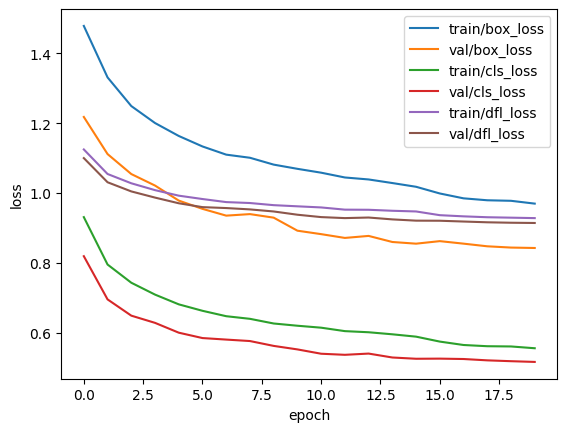

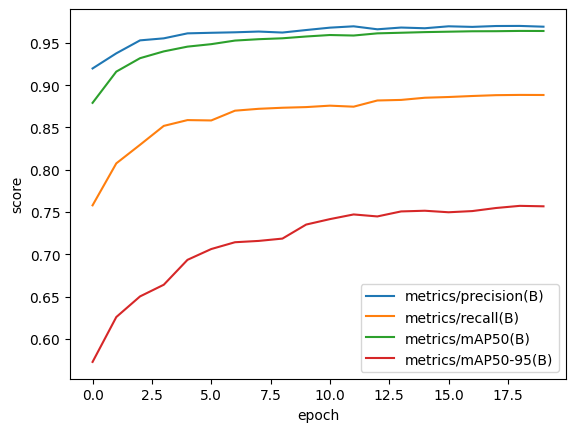

In [27]:
# --- Display training summary + curves (robust path handling) ---
# If plots don't appear in VSCode/Jupyter, keep this:
%matplotlib inline

import os, glob
import pandas as pd
import matplotlib.pyplot as plt

def metric_summary(m):
    out = {}
    # Ultralytics metrics objects vary by version; try common fields safely.
    try: out["precision"] = float(m.box.mp)
    except: pass
    try: out["recall"] = float(m.box.mr)
    except: pass
    try: out["mAP50"] = float(m.box.map50)
    except: pass
    try: out["mAP50-95"] = float(m.box.map)
    except: pass
    return out

# Print before/after metrics if available
if "baseline_metrics" in globals():
    print("BEFORE:", metric_summary(baseline_metrics))
else:
    print("baseline_metrics not found (did the BEFORE val cell run?)")

if "after_metrics" in globals():
    print("AFTER :", metric_summary(after_metrics))
else:
    print("after_metrics not found (did the AFTER val cell run?)")

# --- Find results.csv automatically ---
# Typical locations (based on your screenshot):
# 1) runs/crowdedCondition_yolo/runs/<run_name>/results.csv
# 2) <YOLO_OUT_ROOT>/runs/<run_name>/results.csv
candidates = []

# If YOLO_OUT_ROOT exists, search inside it
if "YOLO_OUT_ROOT" in globals() and YOLO_OUT_ROOT and os.path.exists(YOLO_OUT_ROOT):
    candidates += glob.glob(os.path.join(YOLO_OUT_ROOT, "**", "results.csv"), recursive=True)

# Also search under local ./runs (common ultralytics default)
candidates += glob.glob(os.path.join("runs", "**", "results.csv"), recursive=True)

# Prefer the one that matches your run name, if present
RUN_NAME = "yolov8_mot17_finetune_from_llvip"
preferred = [p for p in candidates if RUN_NAME in p.replace("\\", "/")]
results_csv = preferred[0] if preferred else (candidates[0] if candidates else None)

print("\nFound results.csv:", results_csv)

if results_csv and os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    display(df.tail(10))

    # Loss curves
    plt.figure()
    for key in ["train/box_loss","val/box_loss","train/cls_loss","val/cls_loss","train/dfl_loss","val/dfl_loss"]:
        if key in df.columns:
            plt.plot(df[key], label=key)
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

    # Metric curves
    plt.figure()
    for key in ["metrics/precision(B)","metrics/recall(B)","metrics/mAP50(B)","metrics/mAP50-95(B)"]:
        if key in df.columns:
            plt.plot(df[key], label=key)
    plt.xlabel("epoch"); plt.ylabel("score"); plt.legend(); plt.show()
else:
    print("Could not find results.csv. Check your run folder (it should contain results.csv and results.png).")
